In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.holtwinters import SimpleExpSmoothing
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.metrics import mean_squared_error

In [4]:
df = pd.read_csv("/content/household_water_consumption.csv")
df.head()

,Date,Household_ID,Bathroom_Liters,Kitchen_Liters,Laundry_Liters,Gardening_Liters,Total_Liters
0,2025-01-01,7,248,162,110,100,620
1,2025-01-02,20,321,111,241,7,680
2,2025-01-03,15,253,101,67,52,473
3,2025-01-04,11,363,61,86,59,569
4,2025-01-05,8,368,88,86,107,649


In [5]:
# Convert Date column
df['Date'] = pd.to_datetime(df['Date'])

# Set index
df.set_index('Date', inplace=True)

# Sort (important for time series)
df = df.sort_index()

# Fill missing values if any
df = df.fillna(method='ffill')

/tmp/ipykernel_3583/1072506876.py:11: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill')


In [6]:
ts = df['Total_Liters']

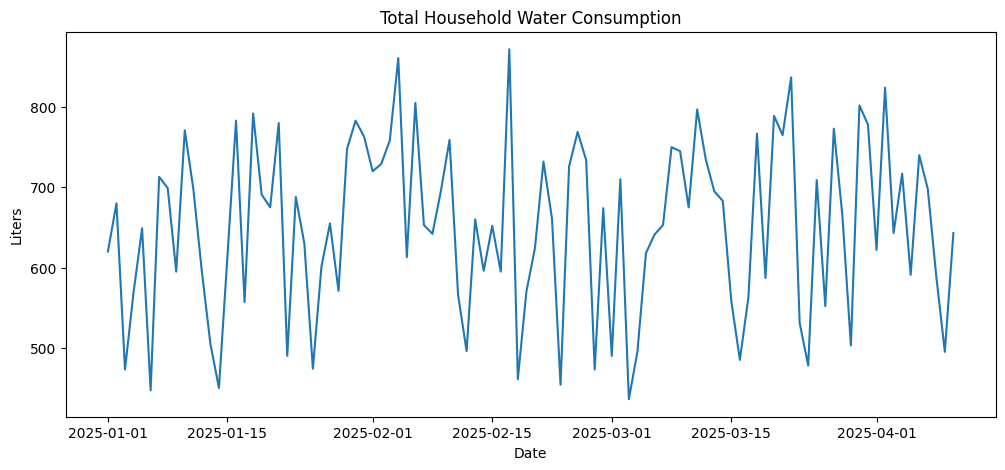

In [7]:
plt.figure(figsize=(12,5))
plt.plot(ts)
plt.title("Total Household Water Consumption")
plt.xlabel("Date")
plt.ylabel("Liters")
plt.show()

/tmp/ipykernel_3583/2901658448.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = ts.resample('M').mean()


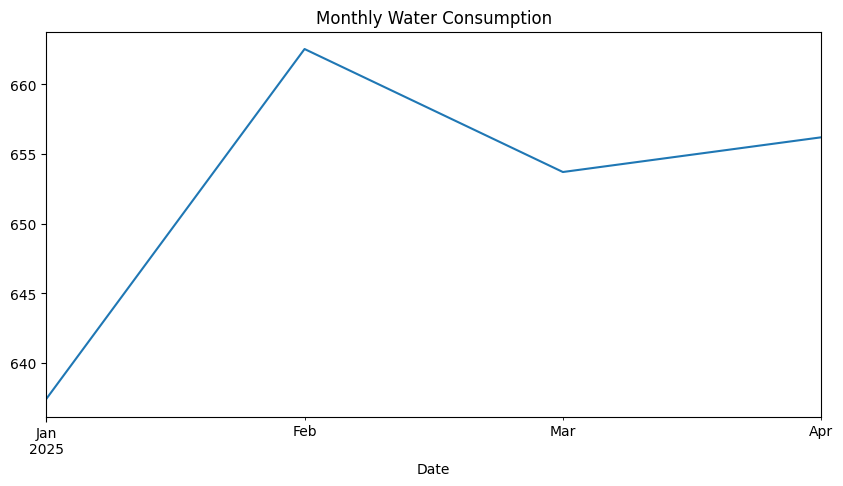

In [8]:
monthly = ts.resample('M').mean()

monthly.plot(figsize=(10,5), title="Monthly Water Consumption")
plt.show()

In [9]:
train = ts[:'2025-03-01']
test = ts['2025-03-02':]

In [10]:
ses_model = SimpleExpSmoothing(train).fit()
ses_forecast = ses_model.forecast(len(test))

print("SES RMSE:", np.sqrt(mean_squared_error(test, ses_forecast)))

SES RMSE: 108.66491271060278


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [11]:
arima_model = ARIMA(train, order=(1,1,1))
arima_fit = arima_model.fit()

arima_forecast = arima_fit.forecast(steps=len(test))

print("ARIMA RMSE:", np.sqrt(mean_squared_error(test, arima_forecast)))

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


ARIMA RMSE: 108.19910292577492


In [12]:
sarima_model = SARIMAX(train,
                      order=(1,1,1),
                      seasonal_order=(1,1,1,12))

sarima_fit = sarima_model.fit()

sarima_forecast = sarima_fit.forecast(steps=len(test))

print("SARIMA RMSE:", np.sqrt(mean_squared_error(test, sarima_forecast)))

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:1009: UserWarning: Non-invertible starting seasonal moving average Using zeros as starting parameters.
  warn('Non-invertible starting seasonal moving average'


SARIMA RMSE: 114.80590753361352


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


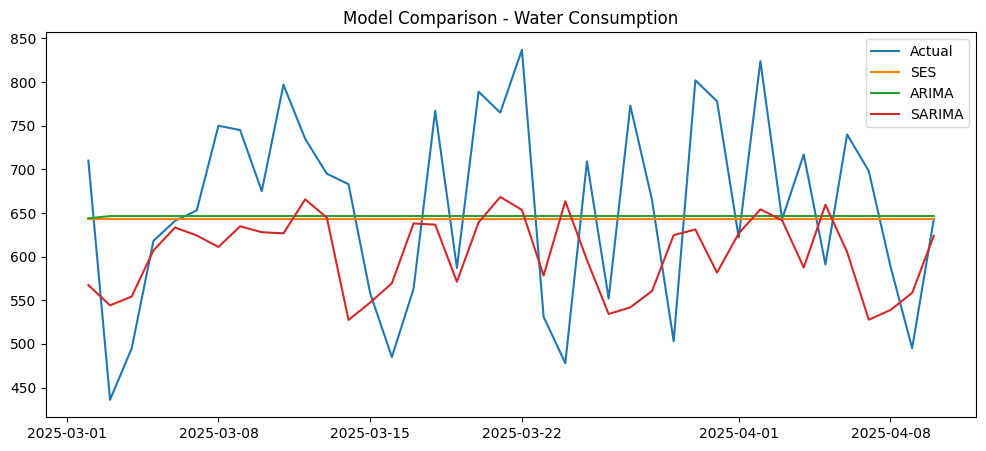

In [13]:
plt.figure(figsize=(12,5))

plt.plot(test, label='Actual')
plt.plot(ses_forecast, label='SES')
plt.plot(arima_forecast, label='ARIMA')
plt.plot(sarima_forecast, label='SARIMA')

plt.legend()
plt.title("Model Comparison - Water Consumption")
plt.show()